# Mean-variance optimal portfolio with transaction costs
## Introduction

As we have seen multiple times during this course, a standard mean–variance investor solves the following asset allocation problem:

$$
\max_w \; w^\top \mu \;-\; \frac{\gamma}{2}\, w^\top \Sigma w
\quad \text{s.t.} \quad \mathbf{1}^\top w = 1,
$$

which leads to the well-known solution:

$$
w^* \propto \Sigma^{-1} \mu
$$

This direct dependence on the inverse covariance matrix and expected returns makes the portfolio **highly sensitive to small estimation errors**. Even minor perturbations in expected returns, volatilities, or correlations can lead to large changes in the optimal weights. For this reason, mean–variance optimisation is often described as an 'error maximizer'.

We start by constructing a standard mean–variance optimal portfolio for a set of hypothetical assets. We then illustrate how a small change in expected returns can lead to a large shift in the optimal portfolio weights. In the final section, we extend the framework by incorporating transaction costs into the objective function, showing how this helps stabilise portfolio allocations and reduces sensitivity to estimation errors.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

In [9]:
# Inputs - 5 assets portfolio:

assets = ["US Equity", "Intl Equity", "US Bonds", "REITs", "Commodities"]

exp_ret = np.array([0.085, 0.078, 0.040, 0.065, 0.055])   # annual expected returns
vols = np.array([0.16, 0.18, 0.06, 0.14, 0.20])               # annual volatilities

corr = np.array([[1.00, 0.82, 0.10, 0.65, 0.35],
                 [0.82, 1.00, 0.05, 0.58, 0.40],
                 [0.10, 0.05, 1.00, 0.15, 0.00],
                 [0.65, 0.58, 0.15, 1.00, 0.30],
                 [0.35, 0.40, 0.00, 0.30, 1.00]])

cov = np.diag(vols) @ corr @ np.diag(vols)

gamma = 4 # risk aversion


In [10]:
# Define portfolio statistics:

def portfolio_stats(w, mu, sigma):
    ret_port = w @ mu
    vol_port = np.sqrt(w @ sigma @ w)
    return ret_port, vol_port

In [11]:
# Optimize portfolio based on mean-variance objective function:

n = len(assets)
x0 = np.repeat(1/n, n)
bounds = [(0.0, 1.0)] * n # long only
base_cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}] # fully invested

res = minimize(lambda w: -((w @ exp_ret) - 0.5*gamma * (w @ cov @ w)),
               x0=x0,
               method="SLSQP",
               bounds=bounds,
               constraints=base_cons)
w = res.x
ret_port, vol_port = portfolio_stats(w, exp_ret, cov)


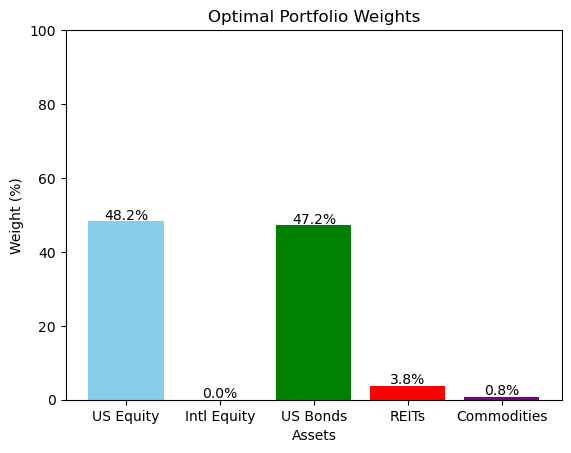

Sum of Portfolio Weights: 100.0
Portfolio Return: 6.28 %,  Portfolio Volatility: 8.88 %


In [12]:
# Plot charts:

w_pct = np.round(w*100,2)

colors = ['skyblue', 'orange', 'green', 'red', 'purple']
plt.bar(assets, w_pct, color=colors)
plt.title("Optimal Portfolio Weights")
plt.xlabel("Assets")
plt.ylabel("Weight (%)")
plt.ylim(0, 100)

for i, v in enumerate(w_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.show()

print("Sum of Portfolio Weights:", round(sum(w)*100,2))
print("Portfolio Return:", round(ret_port*100,2), "%, ", "Portfolio Volatility:", round(vol_port*100,2), "%")


## Mean-Variance optimisation and sensitivity to inputs

Let’s now introduce a small change in one of the assets’ expected returns (REITs) and compare the new optimal allocation with the previous one. This simple exercise illustrates how even a minor perturbation in inputs can lead to a disproportionately large change in portfolio weights.


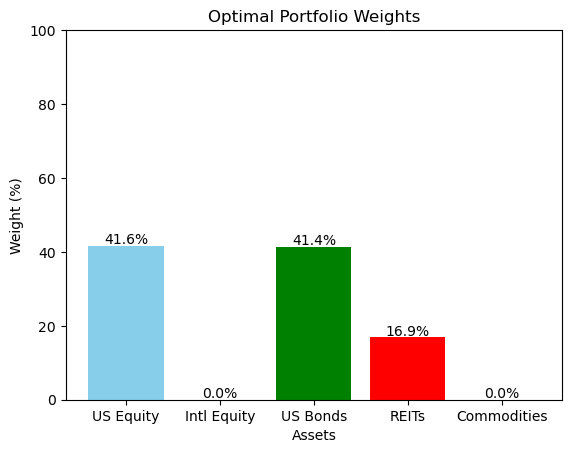

In [13]:
exp_ret_p = exp_ret.copy()   # annual expected returns
exp_ret_p[3] += 0.005  # REITs: 6.5% -> 7.0%

res = minimize(lambda w: -((w @ exp_ret_p) - 0.5*gamma * (w @ cov @ w)),
               x0=x0,
               method="SLSQP",
               bounds=bounds,
               constraints=base_cons)
w_p = res.x
w_p_pct = np.round(w_p*100,2)

colors = ['skyblue', 'orange', 'green', 'red', 'purple']
plt.bar(assets, w_p_pct, color=colors)
plt.title("Optimal Portfolio Weights")
plt.xlabel("Assets")
plt.ylabel("Weight (%)")
plt.ylim(0, 100)

for i, v in enumerate(w_p_pct):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.show()


## Integrating transaction costs

To make the approach more realistic and also to stabilise the allocation, we introduce **transaction costs** by penalizing deviations from the current portfolio $w^0$. The optimisation problem becomes:

$$
max_w \;\max_w \; w^\top \mu \;-\; \frac{\gamma}{2}\, w^\top \Sigma w \;-\; \tau \sum_i |w_i - w_i^{0}|
$$

where $\tau$ controls the magnitude of transaction costs and $\sum_i |w_i - w_i^{0}|$ represents portfolio turnover.

This additional penalty discourages excessive trading, leading to more stable and robust portfolio allocations.

In [14]:
# Optimize portfolio based on mean-variance objective function with transaction costs:

tcost = 0.01

w_prev = np.ones(len(assets)) / len(assets) # Assume current portfolio (e.g., equal weight)

def mv_tcost_fun(w):
    ret = w @ exp_ret
    risk_pen = (0.5*gamma) * (w @ cov @ w)
    turnover = tcost * np.sum(np.abs(w - w_prev))
    return -(ret - risk_pen - turnover) # as in slide 5 of L1

res = minimize(mv_tcost_fun,
               x0=w_prev,  # start from current portfolio
               bounds=bounds,
               constraints=base_cons)
w_tc = res.x

# Compare original optimization (no transaction costs) with transaction costs:
comparison = pd.DataFrame({
    "Asset": assets,
    "No t-cost (%)": np.round(w * 100, 1),
    "With t-cost (%)": np.round(w_tc * 100, 1),
    "Change vs. Prev (%)": np.round((w_tc - w_prev) * 100, 1)})

print(comparison)


         Asset  No t-cost (%)  With t-cost (%)  Change vs. Prev (%)
0    US Equity           48.2             20.0                 -0.0
1  Intl Equity            0.0             19.3                 -0.7
2     US Bonds           47.2             32.2                 12.2
3        REITs            3.8             20.0                  0.0
4  Commodities            0.8              8.5                -11.5


## Time for you to try

Now that you have experimented, you should be able to apply the approaches above to do the following:

1) Try changing either the correlation matrix or the volatility inputs and examine how the optimal portfolio weights change. When doing this, what do you need to be careful about? In particular, make sure that the resulting covariance matrix remains valid. Therefore, after changing volatilities or correlations, check that:

- volatilities remain positive,
- correlations remain between -1 and +1,
- the correlation matrix is symmetric,
- the diagonal elements of the correlation matrix remain equal to 1,
- the covariance matrix is positive semi-definite.

If these conditions are violated, the optimisation problem may produce unreliable or infeasible results.

2) What do you notice happening to the optimal allocation when you change the transaction cost assumption? Apply the code to a time-series dataset of historical returns for different assets. At each point in time, estimate the expected returns and covariance matrix (e.g., using a rolling window), then compute the optimal portfolio weights both with and without transaction costs. How does the allocation change as the transaction cost parameter increases? Can you obtain results similar to those shown in the lecture slides and video lectures?